# Data Visualization, Preprocessing, and Statistical Analysis
**Student Name:** Sandesh Ghimire  


---

## Step 1: Data Collection

This analysis uses the Sample Superstore dataset, a retail sales dataset published on Kaggle that records roughly ten thousand order lines from a US office-supply retailer. Each row carries both transactional measures (sales revenue, quantity, discount, profit) and descriptive attributes (product category, customer segment, shipping mode, geographic region).

Sales data was chosen because the lab brief recommends it and because the measures interact in ways worth investigating: discounting drives volume but erodes margin, and the tension between the two turns out to be visible directly in the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load the Sample Superstore dataset (Kaggle retail sales data)
df = pd.read_csv('SampleSuperstore.csv')

print("Dataset Shape:", df.shape)
print("\nFirst Five Rows of the Dataset:")
print(df.head())

Dataset Shape: (9994, 13)

First Five Rows of the Dataset:
        Ship Mode    Segment        Country             City       State  \
0    Second Class   Consumer  United States        Henderson    Kentucky   
1    Second Class   Consumer  United States        Henderson    Kentucky   
2    Second Class  Corporate  United States      Los Angeles  California   
3  Standard Class   Consumer  United States  Fort Lauderdale     Florida   
4  Standard Class   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region         Category Sub_Category   Sales  Quantity  \
0        42420  South        Furniture    Bookcases  261.96       2.0   
1        42420  South        Furniture       Chairs  731.94       3.0   
2        90036   West  Office Supplies       Labels   14.62       2.0   
3        33311  South        Furniture       Tables  957.58       5.0   
4        33311  South  Office Supplies      Storage   22.37       2.0   

   Discount  Profit  
0      0.00   41.91  
1

In [2]:
# Display basic information about the dataset
print("Dataset Information:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub_Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   float64
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1015.1+ KB
None

Basic Statistics:
        Postal Code         Sales     Quantity     Discount       Profit
count   9994.000000   9994.000000  9994.000000  9994.000000  9994

---
## Step 2: Data Visualization

Data visualization is instrumental in understanding the underlying patterns and relationships within datasets. We employ multiple visualization techniques to uncover insights about retail sales performance.

### Visualization 1: Scatter Plot - Sales vs. Profit

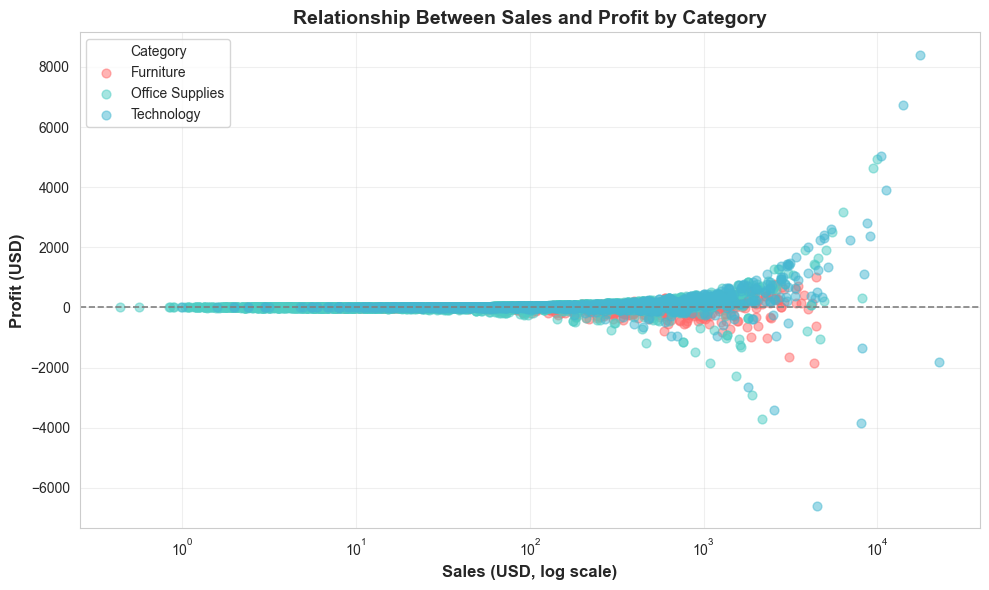


Visualization 1 Insight:
Sales and profit correlate positively (r = 0.48), but the relationship is
far from deterministic: the points fan out into a wedge rather than tracking a line. A substantial band
of orders sits below the zero-profit line, with 18.7% of all orders losing money. Revenue alone
therefore cannot be treated as a proxy for profitability, and the largest orders are not reliably the
most valuable ones. The steepest individual losses come from Furniture and Technology.


In [3]:
# Scatter plot showing relationship between numeric variables
plt.figure(figsize=(10, 6))
category_colors = {'Furniture': '#FF6B6B', 'Office Supplies': '#4ECDC4', 'Technology': '#45B7D1'}

for category in df['Category'].unique():
    category_data = df[df['Category'] == category]
    plt.scatter(category_data['Sales'],
               category_data['Profit'],
               label=category,
               alpha=0.5,
               s=40,
               color=category_colors[category])

plt.axhline(0, color='gray', linewidth=1.2, linestyle='--')
plt.xscale('log')
plt.xlabel('Sales (USD, log scale)', fontsize=12, fontweight='bold')
plt.ylabel('Profit (USD)', fontsize=12, fontweight='bold')
plt.title('Relationship Between Sales and Profit by Category', fontsize=14, fontweight='bold')
plt.legend(title='Category', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

loss_share = (df['Profit'] < 0).mean() * 100
print("\nVisualization 1 Insight:")
print(f"Sales and profit correlate positively (r = {df['Sales'].corr(df['Profit']):.2f}), but the relationship is")
print("far from deterministic: the points fan out into a wedge rather than tracking a line. A substantial band")
print(f"of orders sits below the zero-profit line, with {loss_share:.1f}% of all orders losing money. Revenue alone")
print("therefore cannot be treated as a proxy for profitability, and the largest orders are not reliably the")
print("most valuable ones. The steepest individual losses come from Furniture and Technology.")

### Visualization 2: Box Plot - Distribution of Measures by Category

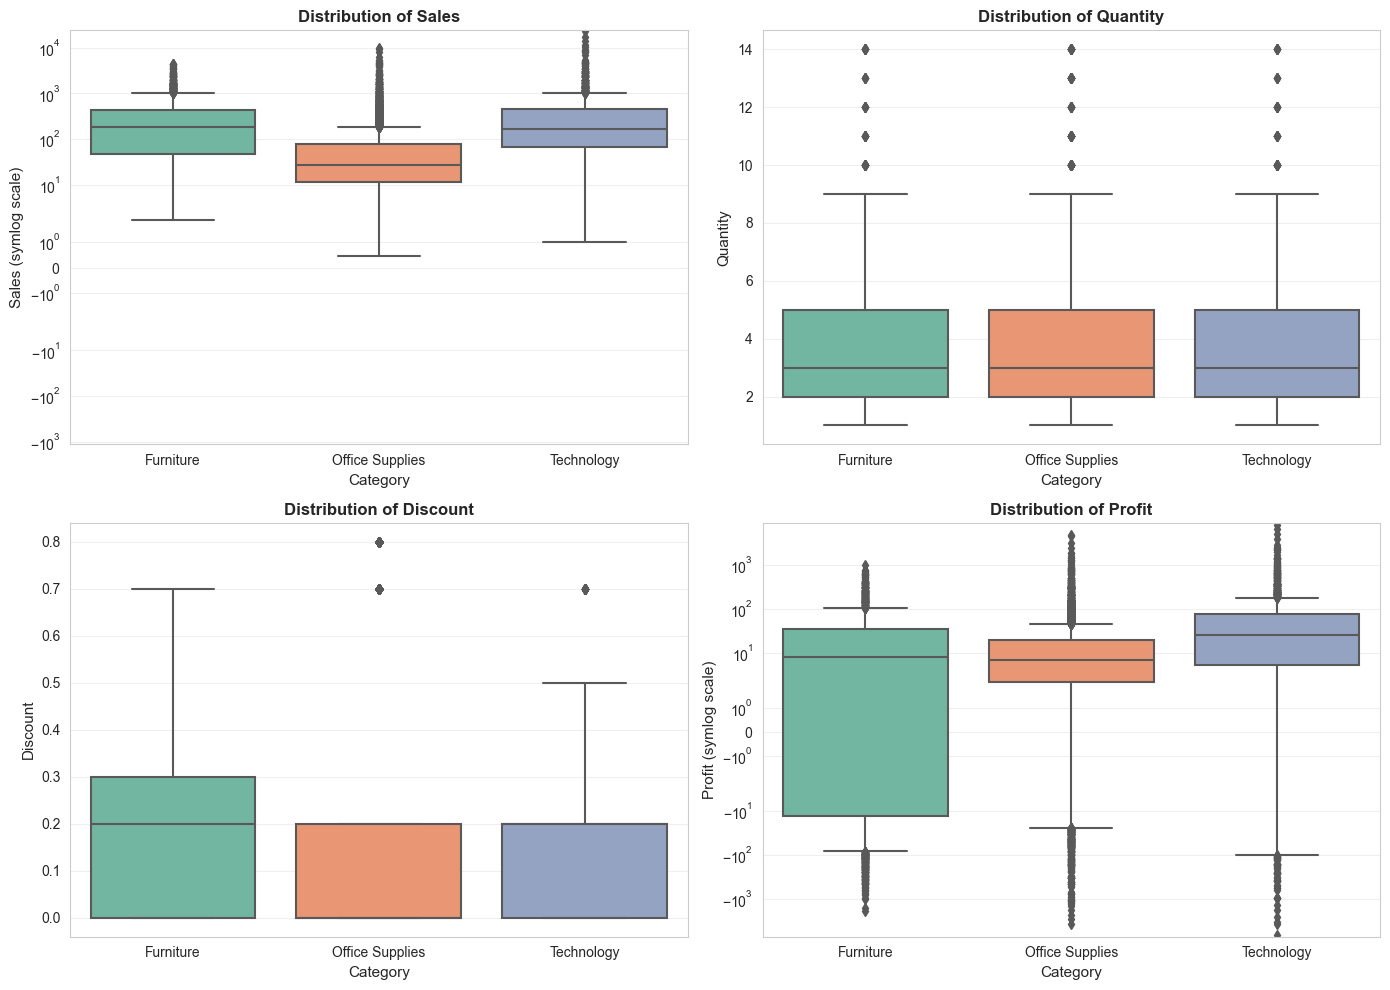


Visualization 2 Insight:
Sales and profit are heavily right-skewed in every category: the boxes sit compressed near the low end
while whiskers and flagged points stretch far above, the signature of retail data where a handful of
large orders dominate revenue. Office Supplies shows the lowest median sales, reflecting many small
consumable purchases, while Technology carries both the highest median profit and the largest single gains.
Discount behaves unlike the monetary measures: it is bounded, clusters at a handful of standard rates
rather than varying continuously, and is applied most aggressively to Furniture.


In [4]:
# Box plots to visualize data spread and outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
measures = ['Sales', 'Quantity', 'Discount', 'Profit']

for idx, measure in enumerate(measures):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(data=df, x='Category', y=measure, ax=ax, palette='Set2')
    ax.set_title(f'Distribution of {measure}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Category', fontsize=11)
    ax.set_ylabel(measure, fontsize=11)
    if measure in ('Sales', 'Profit'):
        ax.set_yscale('symlog')
        ax.set_ylabel(f'{measure} (symlog scale)', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nVisualization 2 Insight:")
print("Sales and profit are heavily right-skewed in every category: the boxes sit compressed near the low end")
print("while whiskers and flagged points stretch far above, the signature of retail data where a handful of")
print("large orders dominate revenue. Office Supplies shows the lowest median sales, reflecting many small")
print("consumable purchases, while Technology carries both the highest median profit and the largest single gains.")
print("Discount behaves unlike the monetary measures: it is bounded, clusters at a handful of standard rates")
print("rather than varying continuously, and is applied most aggressively to Furniture.")

### Visualization 3: Histogram - Distribution of Sales

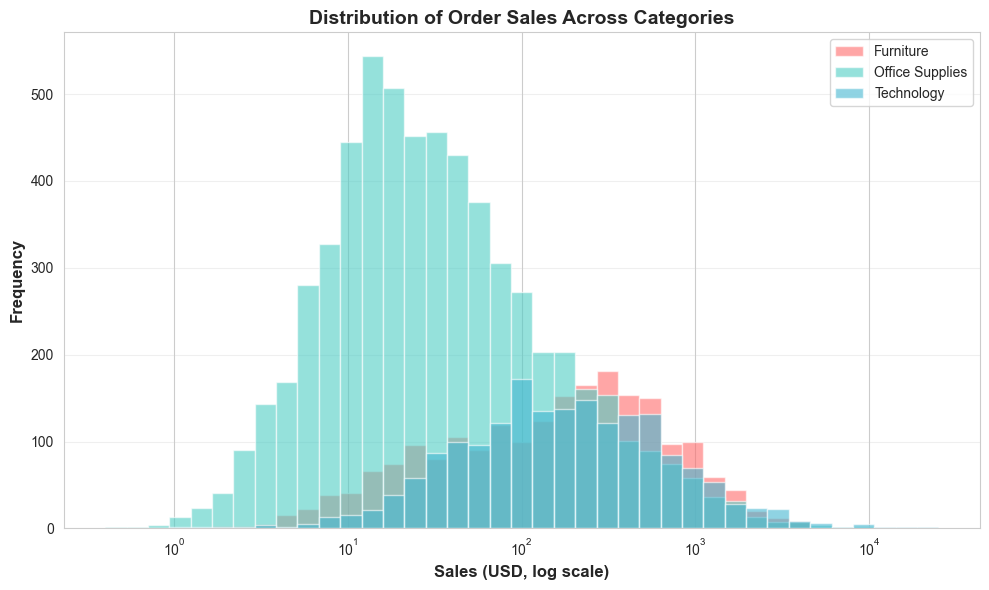


Visualization 3 Insight:
Order values span four orders of magnitude, from $0.44 to $22,638.48, so a
logarithmic axis is needed to see the shape at all. On that scale the distribution is roughly bell-shaped,
which indicates the underlying data is approximately log-normal rather than normal. The practical
consequence is that the mean order ($229.86) sits well above the median ($54.49),
dragged upward by the long right tail, so the median is the more honest summary of a typical order.


In [5]:
# Histogram to display distribution of numerical data
plt.figure(figsize=(10, 6))
log_bins = np.logspace(np.log10(0.4), np.log10(25000), 40)

for category in df['Category'].unique():
    category_data = df[df['Category'] == category]['Sales']
    plt.hist(category_data, alpha=0.6, label=category, bins=log_bins,
             color=category_colors[category])

plt.xscale('log')
plt.xlabel('Sales (USD, log scale)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Distribution of Order Sales Across Categories', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nVisualization 3 Insight:")
print(f"Order values span four orders of magnitude, from ${df['Sales'].min():.2f} to ${df['Sales'].max():,.2f}, so a")
print("logarithmic axis is needed to see the shape at all. On that scale the distribution is roughly bell-shaped,")
print("which indicates the underlying data is approximately log-normal rather than normal. The practical")
print(f"consequence is that the mean order (${df['Sales'].mean():.2f}) sits well above the median (${df['Sales'].median():.2f}),")
print("dragged upward by the long right tail, so the median is the more honest summary of a typical order.")

---
## Step 3: Data Preprocessing

Data preprocessing is a critical phase in the analytical pipeline, encompassing techniques to enhance data quality and suitability for statistical analysis and machine learning applications.

### 3.1: Handling Missing Values

The published dataset arrives complete, so missing values are introduced deliberately below in order to demonstrate detection and imputation. This is a teaching device rather than a property of the source data, and the fixed random seed keeps it reproducible.

In [6]:
# Check for missing values in the original dataset
print("Missing Values in Original Dataset:")
missing_count = df.isnull().sum()
print(missing_count)
print(f"\nTotal Missing Values: {missing_count.sum()}")

# Create a copy for demonstration purposes
df_with_missing = df.copy()

# Artificially introduce missing values to demonstrate preprocessing techniques
np.random.seed(42)
missing_indices = np.random.choice(df_with_missing.index, size=300, replace=False)
df_with_missing.loc[missing_indices, 'Discount'] = np.nan

missing_indices_2 = np.random.choice(df_with_missing.index, size=150, replace=False)
df_with_missing.loc[missing_indices_2, 'Quantity'] = np.nan

print("\n" + "="*60)
print("Missing Values After Introducing NaN:")
print("="*60)
print(df_with_missing.isnull().sum())
print(f"\nTotal Missing Values: {df_with_missing.isnull().sum().sum()}")

Missing Values in Original Dataset:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub_Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Total Missing Values: 0

Missing Values After Introducing NaN:
Ship Mode         0
Segment           0
Country           0
City              0
State             0
Postal Code       0
Region            0
Category          0
Sub_Category      0
Sales             0
Quantity        150
Discount        300
Profit            0
dtype: int64

Total Missing Values: 450


In [7]:
# Handle missing values using mean and median imputation
df_imputed = df_with_missing.copy()

fill_discount = df_with_missing['Discount'].mean()
fill_quantity = df_with_missing['Quantity'].median()

# Discount is bounded and roughly symmetric, so the mean is a reasonable fill
df_imputed['Discount'].fillna(fill_discount, inplace=True)

# Quantity is a right-skewed count, so the median avoids inventing fractional averages
df_imputed['Quantity'].fillna(fill_quantity, inplace=True)

print("After Imputation:")
print(df_imputed.isnull().sum())
print(f"\nDataset shape: {df_imputed.shape}")
print("\nAll missing values have been successfully imputed.")
print(f"\nDiscount mean used for fill  : {fill_discount:.4f}")
print(f"Quantity median used for fill: {fill_quantity:.4f}")
print("\nCaveat: imputing with a single constant shrinks the variance of the affected column,")
print("because every filled row now sits exactly at the centre of the distribution.")

After Imputation:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub_Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Dataset shape: (9994, 13)

All missing values have been successfully imputed.

Discount mean used for fill  : 0.1562
Quantity median used for fill: 3.0000

Caveat: imputing with a single constant shrinks the variance of the affected column,
because every filled row now sits exactly at the centre of the distribution.


### 3.2: Outlier Detection and Removal

In [8]:
# Outlier detection using Interquartile Range (IQR) method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound, IQR

# Apply IQR method to Sales
column = 'Sales'
lower, upper, iqr = detect_outliers_iqr(df_imputed, column)

print(f"Outlier Detection for '{column}':")
print(f"Q1 (25th percentile): {df_imputed[column].quantile(0.25):.2f}")
print(f"Q3 (75th percentile): {df_imputed[column].quantile(0.75):.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Lower Bound: {lower:.2f}")
print(f"Upper Bound: {upper:.2f}")

# Identify outliers
outliers = df_imputed[(df_imputed[column] < lower) | (df_imputed[column] > upper)]
print(f"\nNumber of Outliers Detected: {len(outliers)} ({len(outliers)/len(df_imputed)*100:.1f}% of rows)")
print(f"\nTen Largest Outliers by {column}:")
print(outliers.nlargest(10, column)[['Category', 'Sub_Category', 'Sales', 'Quantity', 'Discount', 'Profit']])

Outlier Detection for 'Sales':
Q1 (25th percentile): 17.28
Q3 (75th percentile): 209.94
IQR: 192.66
Lower Bound: -271.71
Upper Bound: 498.93

Number of Outliers Detected: 1167 (11.7% of rows)

Ten Largest Outliers by Sales:
             Category Sub_Category     Sales  Quantity  Discount   Profit
2697       Technology     Machines  22638.48       6.0       0.5 -1811.08
6826       Technology      Copiers  17499.95       5.0       0.0  8399.98
8153       Technology      Copiers  13999.96       3.0       0.0  6719.98
2623       Technology      Copiers  11199.97       4.0       0.2  3919.99
4190       Technology      Copiers  10499.97       3.0       0.0  5039.99
9039  Office Supplies      Binders   9892.74      13.0       0.0  4946.37
4098  Office Supplies      Binders   9449.95       5.0       0.0  4630.48
4277       Technology     Machines   9099.93       7.0       0.0  2365.98
8488       Technology     Machines   8749.95       5.0       0.0  2799.98
6425       Technology      Copiers  

In [9]:
# Remove outliers
df_no_outliers = df_imputed[(df_imputed[column] >= lower) & (df_imputed[column] <= upper)]

print(f"Dataset Shape Before Outlier Removal: {df_imputed.shape}")
print(f"Dataset Shape After Outlier Removal: {df_no_outliers.shape}")
print(f"\nRows Removed: {len(df_imputed) - len(df_no_outliers)}")

revenue_before = df_imputed['Sales'].sum()
revenue_after = df_no_outliers['Sales'].sum()
print(f"\nTotal revenue before: ${revenue_before:,.2f}")
print(f"Total revenue after : ${revenue_after:,.2f}")
print(f"Share of revenue discarded: {(1 - revenue_after/revenue_before)*100:.1f}%")
print("\nNote: inspection of the flagged rows shows genuine large orders, not recording errors. Removing them")
print("is defensible when modelling the typical transaction, but it discards a large share of total revenue,")
print("so for any revenue-forecasting task they should be retained or modelled as a separate segment.")

Dataset Shape Before Outlier Removal: (9994, 13)
Dataset Shape After Outlier Removal: (8827, 13)

Rows Removed: 1167

Total revenue before: $2,297,201.07
Total revenue after : $819,718.16
Share of revenue discarded: 64.3%

Note: inspection of the flagged rows shows genuine large orders, not recording errors. Removing them
is defensible when modelling the typical transaction, but it discards a large share of total revenue,
so for any revenue-forecasting task they should be retained or modelled as a separate segment.


### 3.3: Data Reduction

In [10]:
# Data reduction through sampling
print("Original Dataset Shape:", df_no_outliers.shape)

# Method 1: Sample by percentage (e.g., 70% of data)
df_sampled = df_no_outliers.sample(frac=0.7, random_state=42)
print(f"\nSampled Dataset (70%): {df_sampled.shape}")

# Method 2: Sample by fixed number of rows
df_sampled_fixed = df_no_outliers.sample(n=1000, random_state=42)
print(f"Sampled Dataset (1000 rows): {df_sampled_fixed.shape}")

# Confirm the sample still represents the population
print("\nRepresentativeness check:")
print("  Mean Sales  - full: {:8.2f} | 70% sample: {:8.2f}".format(
    df_no_outliers['Sales'].mean(), df_sampled['Sales'].mean()))
print("  Mean Profit - full: {:8.2f} | 70% sample: {:8.2f}".format(
    df_no_outliers['Profit'].mean(), df_sampled['Profit'].mean()))
print("\nData reduction through sampling completed successfully.")

Original Dataset Shape: (8827, 13)

Sampled Dataset (70%): (6179, 13)
Sampled Dataset (1000 rows): (1000, 13)

Representativeness check:
  Mean Sales  - full:    92.86 | 70% sample:    92.03
  Mean Profit - full:    11.20 | 70% sample:    11.07

Data reduction through sampling completed successfully.


In [11]:
# Dimension elimination - drop less relevant columns
print("Columns Before Dimension Elimination:")
print(df_sampled.columns.tolist())
print(f"Number of Columns: {len(df_sampled.columns)}")

print("\nJustification:")
print(f"  Country     - {df_sampled['Country'].nunique()} unique value(s), so it carries no information")
print(f"  Postal Code - {df_sampled['Postal Code'].nunique()} unique values, an identifier rather than a measure")
print(f"  City        - {df_sampled['City'].nunique()} unique values, too granular; Region and State keep the geography")

df_reduced = df_sampled.drop(columns=['Country', 'Postal Code', 'City'])

print("\nColumns After Dimension Elimination:")
print(df_reduced.columns.tolist())
print(f"Number of Columns: {len(df_reduced.columns)}")
print(f"\nDataset Shape: {df_reduced.shape}")

Columns Before Dimension Elimination:
['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub_Category', 'Sales', 'Quantity', 'Discount', 'Profit']
Number of Columns: 13

Justification:
  Country     - 1 unique value(s), so it carries no information
  Postal Code - 591 unique values, an identifier rather than a measure
  City        - 494 unique values, too granular; Region and State keep the geography

Columns After Dimension Elimination:
['Ship Mode', 'Segment', 'State', 'Region', 'Category', 'Sub_Category', 'Sales', 'Quantity', 'Discount', 'Profit']
Number of Columns: 10

Dataset Shape: (6179, 10)


### 3.4: Data Scaling and Discretization

In [12]:
# Data Scaling using Min-Max Normalization
from sklearn.preprocessing import MinMaxScaler, StandardScaler

numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

print("Before Scaling:")
print(df_reduced[numeric_cols].describe())

# Apply Min-Max Scaling
scaler = MinMaxScaler()
df_scaled = df_reduced.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_reduced[numeric_cols])

print("\n" + "="*60)
print("After Min-Max Scaling:")
print("="*60)
print(df_scaled[numeric_cols].describe())
print("\nEvery measure now occupies the same [0, 1] range, so no column dominates a distance")
print("calculation purely because it happens to be denominated in dollars rather than units.")

Before Scaling:
             Sales     Quantity     Discount       Profit
count  6179.000000  6179.000000  6179.000000  6179.000000
mean     92.033369     3.610940     0.157148    11.073717
std     113.653462     2.100837     0.207968    46.522715
min       0.560000     1.000000     0.000000  -766.010000
25%      15.180000     2.000000     0.000000     1.700000
50%      40.240000     3.000000     0.156197     7.480000
75%     121.570000     5.000000     0.200000    21.040000
max     497.940000    14.000000     0.800000   240.860000

After Min-Max Scaling:
             Sales     Quantity     Discount       Profit
count  6179.000000  6179.000000  6179.000000  6179.000000
mean      0.183910     0.200842     0.196435     0.771782
std       0.228504     0.161603     0.259960     0.046205
min       0.000000     0.000000     0.000000     0.000000
25%       0.029394     0.076923     0.000000     0.762472
50%       0.079778     0.153846     0.195246     0.768212
75%       0.243295     0.307692 

In [13]:
# Z-score Standardization
scaler_zscore = StandardScaler()
df_standardized = df_reduced.copy()
df_standardized[numeric_cols] = scaler_zscore.fit_transform(df_reduced[numeric_cols])

print("After Z-score Standardization:")
print(df_standardized[numeric_cols].describe())
print("\nNote: Standardized values have mean = 0 and standard deviation = 1")
print("A value of +2 now reads as 'two standard deviations above average', which is directly")
print("comparable across Sales, Quantity, Discount and Profit.")

After Z-score Standardization:
              Sales      Quantity      Discount        Profit
count  6.179000e+03  6.179000e+03  6.179000e+03  6.179000e+03
mean   5.634665e-17 -8.883222e-17  5.174692e-17  1.149932e-18
std    1.000081e+00  1.000081e+00  1.000081e+00  1.000081e+00
min   -8.049097e-01 -1.242910e+00 -7.556964e-01 -1.670467e+01
25%   -6.762626e-01 -7.668709e-01 -7.556964e-01 -2.015032e-01
50%   -4.557500e-01 -2.908316e-01 -4.575258e-03 -7.725276e-02
75%    2.599043e-01  6.612470e-01  2.060673e-01  2.142413e-01
max    3.571730e+00  4.945601e+00  3.091358e+00  4.939627e+00

Note: Standardized values have mean = 0 and standard deviation = 1
A value of +2 now reads as 'two standard deviations above average', which is directly
comparable across Sales, Quantity, Discount and Profit.


In [14]:
# Discretization - convert continuous Sales into categorical bands
print("Before Discretization:")
print(df_reduced['Sales'].describe())

# Create bins for order-value categorization
bins = [0, 50, 150, 300, np.inf]
labels = ['Small', 'Medium', 'Large', 'Premium']

df_discretized = df_reduced.copy()
df_discretized['sales_band'] = pd.cut(df_discretized['Sales'],
                                      bins=bins,
                                      labels=labels,
                                      right=True)

print("\n" + "="*60)
print("After Discretization:")
print("="*60)
print(df_discretized[['Sales', 'sales_band']].head(10))
print("\nBand Distribution:")
print(df_discretized['sales_band'].value_counts().sort_index())

print("\nMean Profit by Sales Band:")
print(df_discretized.groupby('sales_band')['Profit'].mean().round(2))
print("\nBanding trades precision for readability: the exact order value is lost, but the bands map")
print("onto categories a sales team would actually reason about.")

Before Discretization:
count    6179.000000
mean       92.033369
std       113.653462
min         0.560000
25%        15.180000
50%        40.240000
75%       121.570000
max       497.940000
Name: Sales, dtype: float64

After Discretization:
       Sales sales_band
1152    3.64      Small
9016   11.42      Small
6910  115.96     Medium
7043  198.74      Large
7512  239.46      Large
1474   17.28      Small
3225   12.77      Small
1065    1.45      Small
3885   12.13      Small
6957   51.75     Medium

Band Distribution:
sales_band
Small      3398
Medium     1470
Large       796
Premium     515
Name: count, dtype: int64

Mean Profit by Sales Band:
sales_band
Small       3.75
Medium     15.24
Large      24.13
Premium    27.32
Name: Profit, dtype: float64

Banding trades precision for readability: the exact order value is lost, but the bands map
onto categories a sales team would actually reason about.


---
## Step 4: Statistical Analysis

Statistical analysis provides quantitative insights into the distributional properties and relationships within the dataset. We employ descriptive statistics and correlation measures to characterize our data comprehensively.

### 4.1: General Overview of Data

In [15]:
# Display dataset information
print("Dataset Information:")
print("="*60)
df_reduced.info()

print("\n" + "="*60)
print("Descriptive Statistics:")
print("="*60)
print(df_reduced.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 6179 entries, 1152 to 4806
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     6179 non-null   object 
 1   Segment       6179 non-null   object 
 2   State         6179 non-null   object 
 3   Region        6179 non-null   object 
 4   Category      6179 non-null   object 
 5   Sub_Category  6179 non-null   object 
 6   Sales         6179 non-null   float64
 7   Quantity      6179 non-null   float64
 8   Discount      6179 non-null   float64
 9   Profit        6179 non-null   float64
dtypes: float64(4), object(6)
memory usage: 531.0+ KB

Descriptive Statistics:
             Sales     Quantity     Discount       Profit
count  6179.000000  6179.000000  6179.000000  6179.000000
mean     92.033369     3.610940     0.157148    11.073717
std     113.653462     2.100837     0.207968    46.522715
min       0.560000     1.000000     0.000000  -

### 4.2: Central Tendency Measures

In [16]:
# Calculate central tendency measures
numeric_features = ['Sales', 'Quantity', 'Discount', 'Profit']

print("Central Tendency Measures:")
print("="*70)

for feature in numeric_features:
    print(f"\n{feature.upper()}:")
    print(f"  Minimum:  {df_reduced[feature].min():.4f}")
    print(f"  Maximum:  {df_reduced[feature].max():.4f}")
    print(f"  Mean:     {df_reduced[feature].mean():.4f}")
    print(f"  Median:   {df_reduced[feature].median():.4f}")
    print(f"  Mode:     {df_reduced[feature].mode().values[0]:.4f}")

# Create summary dataframe
summary_stats = pd.DataFrame({
    'Minimum': df_reduced[numeric_features].min(),
    'Maximum': df_reduced[numeric_features].max(),
    'Mean': df_reduced[numeric_features].mean(),
    'Median': df_reduced[numeric_features].median(),
    'Mode': df_reduced[numeric_features].mode().iloc[0]
})

print("\n" + "="*70)
print("Summary Table:")
print(summary_stats.round(4))
print("\nSales and Profit both show mean above median, the signature of right skew. Discount has a")
print("mode of zero, confirming that the single most common case is no discount at all.")

Central Tendency Measures:

SALES:
  Minimum:  0.5600
  Maximum:  497.9400
  Mean:     92.0334
  Median:   40.2400
  Mode:     12.9600

QUANTITY:
  Minimum:  1.0000
  Maximum:  14.0000
  Mean:     3.6109
  Median:   3.0000
  Mode:     3.0000

DISCOUNT:
  Minimum:  0.0000
  Maximum:  0.8000
  Mean:     0.1571
  Median:   0.1562
  Mode:     0.0000

PROFIT:
  Minimum:  -766.0100
  Maximum:  240.8600
  Mean:     11.0737
  Median:   7.4800
  Mode:     6.2200

Summary Table:
          Minimum  Maximum     Mean   Median   Mode
Sales        0.56   497.94  92.0334  40.2400  12.96
Quantity     1.00    14.00   3.6109   3.0000   3.00
Discount     0.00     0.80   0.1571   0.1562   0.00
Profit    -766.01   240.86  11.0737   7.4800   6.22

Sales and Profit both show mean above median, the signature of right skew. Discount has a
mode of zero, confirming that the single most common case is no discount at all.


### 4.3: Dispersion Measures

In [17]:
# Calculate dispersion measures
print("Dispersion Measures:")
print("="*70)

for feature in numeric_features:
    data = df_reduced[feature]
    print(f"\n{feature.upper()}:")
    print(f"  Range:                {data.max() - data.min():.4f}")
    print(f"  Q1 (25th percentile): {data.quantile(0.25):.4f}")
    print(f"  Q2 (50th percentile): {data.quantile(0.50):.4f}")
    print(f"  Q3 (75th percentile): {data.quantile(0.75):.4f}")
    print(f"  IQR:                  {data.quantile(0.75) - data.quantile(0.25):.4f}")
    print(f"  Variance:             {data.var():.4f}")
    print(f"  Std Deviation:        {data.std():.4f}")
    print(f"  Coefficient of Var.:  {(data.std() / data.mean() * 100):.2f}%")

# Create summary dataframe
dispersion_stats = pd.DataFrame({
    'Range': df_reduced[numeric_features].max() - df_reduced[numeric_features].min(),
    'IQR': df_reduced[numeric_features].quantile(0.75) - df_reduced[numeric_features].quantile(0.25),
    'Variance': df_reduced[numeric_features].var(),
    'Std Dev': df_reduced[numeric_features].std(),
    'CV (%)': (df_reduced[numeric_features].std() / df_reduced[numeric_features].mean() * 100)
})

print("\n" + "="*70)
print("Summary Table:")
print(dispersion_stats.round(4))
print("\nProfit carries by far the highest coefficient of variation. Its mean sits close to zero while")
print("individual orders swing to both gains and losses, so relative variability explodes. Profit is the")
print("least stable measure here and the hardest to predict from order size alone.")

Dispersion Measures:

SALES:
  Range:                497.3800
  Q1 (25th percentile): 15.1800
  Q2 (50th percentile): 40.2400
  Q3 (75th percentile): 121.5700
  IQR:                  106.3900
  Variance:             12917.1095
  Std Deviation:        113.6535
  Coefficient of Var.:  123.49%

QUANTITY:
  Range:                13.0000
  Q1 (25th percentile): 2.0000
  Q2 (50th percentile): 3.0000
  Q3 (75th percentile): 5.0000
  IQR:                  3.0000
  Variance:             4.4135
  Std Deviation:        2.1008
  Coefficient of Var.:  58.18%

DISCOUNT:
  Range:                0.8000
  Q1 (25th percentile): 0.0000
  Q2 (50th percentile): 0.1562
  Q3 (75th percentile): 0.2000
  IQR:                  0.2000
  Variance:             0.0433
  Std Deviation:        0.2080
  Coefficient of Var.:  132.34%

PROFIT:
  Range:                1006.8700
  Q1 (25th percentile): 1.7000
  Q2 (50th percentile): 7.4800
  Q3 (75th percentile): 21.0400
  IQR:                  19.3400
  Variance:        

### 4.4: Correlation Analysis

In [18]:
# Compute correlation matrix
correlation_matrix = df_reduced[numeric_features].corr()

print("Correlation Matrix:")
print("="*70)
print(correlation_matrix.round(4))

# Interpretation of correlations
print("\n" + "="*70)
print("Correlation Analysis Interpretation:")
print("="*70)
print("\n1. Sales vs. Profit:    r =", f"{correlation_matrix.loc['Sales', 'Profit']:.4f}")
print("   Positive but moderate: larger orders tend to earn more, yet order size explains only part")
print("   of the variation in profit.")
print("\n2. Discount vs. Profit: r =", f"{correlation_matrix.loc['Discount', 'Profit']:.4f}")
print("   Negative, and the most actionable relationship in the dataset: heavier discounting is")
print("   associated with worse profit outcomes.")
print("\n3. Sales vs. Quantity:  r =", f"{correlation_matrix.loc['Sales', 'Quantity']:.4f}")
print("   Weakly positive, because unit price varies so widely that item count is a poor proxy for revenue.")

# Quantify the discount effect directly
profitable = df_reduced[df_reduced['Profit'] >= 0]['Discount'].mean()
loss_making = df_reduced[df_reduced['Profit'] < 0]['Discount'].mean()
print("\n" + "="*70)
print(f"Mean discount on profitable orders  : {profitable:.3f}")
print(f"Mean discount on loss-making orders : {loss_making:.3f}")
print("\nThe gap between these two figures makes the correlation concrete. Note that this is an")
print("observational association, not proof of causation: discounts may be applied preferentially to")
print("products that were already low-margin or slow-moving.")

Correlation Matrix:
           Sales  Quantity  Discount  Profit
Sales     1.0000    0.1462   -0.0704  0.1973
Quantity  0.1462    1.0000    0.0147  0.0901
Discount -0.0704    0.0147    1.0000 -0.4521
Profit    0.1973    0.0901   -0.4521  1.0000

Correlation Analysis Interpretation:

1. Sales vs. Profit:    r = 0.1973
   Positive but moderate: larger orders tend to earn more, yet order size explains only part
   of the variation in profit.

2. Discount vs. Profit: r = -0.4521
   Negative, and the most actionable relationship in the dataset: heavier discounting is
   associated with worse profit outcomes.

3. Sales vs. Quantity:  r = 0.1462
   Weakly positive, because unit price varies so widely that item count is a poor proxy for revenue.

Mean discount on profitable orders  : 0.083
Mean discount on loss-making orders : 0.489

The gap between these two figures makes the correlation concrete. Note that this is an
observational association, not proof of causation: discounts may be applied

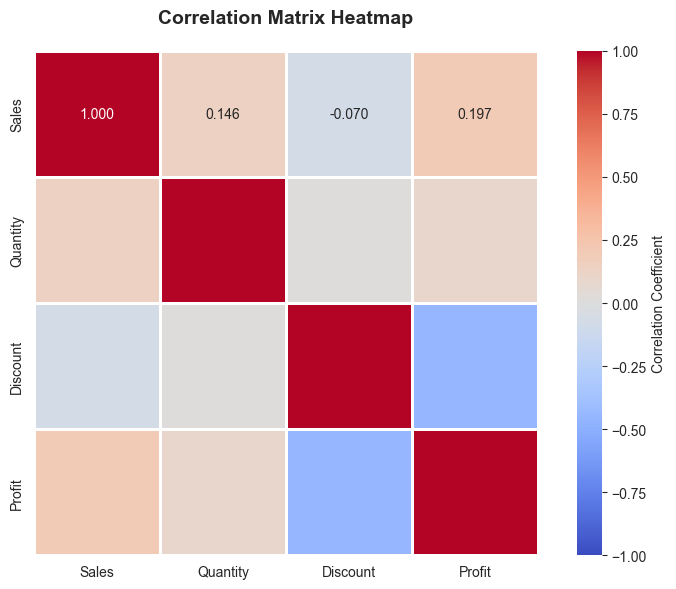

Heatmap visualization completed.


In [19]:
# Visualize correlation matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=2, cbar_kws={'label': 'Correlation Coefficient'},
            vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Heatmap visualization completed.")

---
## Conclusion

This analysis worked through the full data science pipeline on roughly ten thousand real retail orders: collection, exploratory visualization, preprocessing, and statistical characterization.

The substantive finding is that revenue and profitability come apart. Sales and profit correlate only moderately, close to a fifth of all orders lose money, and discount level shows a clear negative association with profit, with loss-making orders carrying a far heavier average discount than profitable ones. For a retailer, that points at discount policy rather than sales volume as the lever worth examining.

Two methodological points emerged from the preprocessing work. First, the IQR rule flagged a large share of sales as outliers, but inspection showed these were legitimate large orders rather than data errors, and removing them discarded a substantial portion of total revenue. An automated rule is a starting point for investigation, not a decision. Second, the monetary measures are strongly right-skewed, so the mean overstates a typical order and the median is the more faithful summary.

Natural extensions include testing whether the discount-profit relationship holds within each product sub-category, modelling profit from order attributes, and treating the large-order segment separately rather than discarding it.

---
**End of Lab Report**